# Notebook 00: Kiểm kê Dữ liệu & Đảm bảo Tính Toàn vẹn Thực nghiệm

> **Mục đích**: Đối chiếu, kiểm tra tính toàn vẹn của ba bộ dữ liệu thực nghiệm trước khi bước vào quy trình huấn luyện:
> 1. Dữ liệu bảng: **Diabetes 130-US Hospitals** (UCI ML Repository #296)
> 2. Dữ liệu ảnh grayscale: **MNIST Handwritten Digits** (LeCun et al., 1998)
> 3. Dữ liệu ảnh màu tự nhiên: **CIFAR-10 Object Recognition** (Krizhevsky, 2009)
>
> Thực hiện nguyên tắc công bằng (*The Fairness Rule* - Lecture 04, Slide 29): Đảm bảo toàn bộ ba framework (**Scratch NumPy**, **TensorFlow/Keras**, **PyTorch**) nhận chung một tập dữ liệu, chung phép chia train/test (seed=42) và chung định dạng chuẩn hóa.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ass4_utils as U

U.set_seed(42)
print("Environment setup verified.")
print(f"Data directory: {U.DATA}")

Environment setup verified.
Data directory: E:\smart system\intel_sys_A4\data


## 1. Kiểm kê Bộ Dữ liệu Bảng: Diabetes 130-US Hospitals (UCI)

Bộ dữ liệu gồm hồ sơ điều trị nội trú của các bệnh nhân tiểu đường tại 130 bệnh viện Hoa Kỳ (1999–2008). Nhiệm vụ là dự đoán khả năng tái nhập viện (`readmitted`) thuộc 3 lớp: `NO`, `>30` ngày, hoặc `<30` ngày.

In [2]:
csv_path = U._download_diabetes130()
print(f"CSV Path: {csv_path}")
print(f"File size: {os.path.getsize(csv_path) / (1024*1024):.2f} MB")

df_raw = pd.read_csv(csv_path)
print(f"Total records: {len(df_raw):,} rows, {df_raw.shape[1]} columns")

print("\nFirst 3 rows:")
display(df_raw.head(3))

CSV Path: E:\smart system\intel_sys_A4\data\diabetes130\diabetic_data.csv
File size: 18.27 MB


Total records: 101,766 rows, 50 columns

First 3 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


In [3]:
print("Class distribution in raw data (readmitted):")
dist = df_raw['readmitted'].value_counts()
pct = df_raw['readmitted'].value_counts(normalize=True) * 100
summary_dist = pd.DataFrame({'Count': dist, 'Percentage (%)': pct})
display(summary_dist)

print("\nHigh-missing features dropped:")
for c in U._DROP_COLS:
    if c in df_raw.columns:
        n_miss = (df_raw[c] == '?').sum()
        print(f" - {c:<20}: {n_miss:>6,} missing ({n_miss/len(df_raw)*100:5.2f}%)")

Class distribution in raw data (readmitted):


,Count,Percentage (%)
readmitted,,
NO,54864,53.911916
>30,35545,34.928169
<30,11357,11.159916



High-missing features dropped:
 - encounter_id        :      0 missing ( 0.00%)
 - patient_nbr         :      0 missing ( 0.00%)
 - weight              : 98,569 missing (96.86%)
 - payer_code          : 40,256 missing (39.56%)
 - medical_specialty   : 49,949 missing (49.08%)


In [4]:
X_train, y_train, X_test, y_test, meta = U.load_diabetes130()
print(f"Processed Tabular Features:")
print(f" - X_train: {X_train.shape}, dtype: {X_train.dtype}")
print(f" - y_train: {y_train.shape}, dtype: {y_train.dtype}")
print(f" - X_test : {X_test.shape}, dtype: {X_test.dtype}")
print(f" - y_test : {y_test.shape}, dtype: {y_test.dtype}")
print(f" - Feature count after One-Hot Encoding: {X_train.shape[1]}")
print(f" - Target classes: {U.READMIT_CLASSES}")

Diabetes 130-US hospitals: raw (101766, 50) -> (69973, 179), train 55979 / test 13994, 179 features, 3 classes
Processed Tabular Features:
 - X_train: (55979, 179), dtype: float32
 - y_train: (55979,), dtype: int64
 - X_test : (13994, 179), dtype: float32
 - y_test : (13994,), dtype: int64
 - Feature count after One-Hot Encoding: 179
 - Target classes: ['NO', '>30', '<30']


## 2. Kiểm kê Bộ Dữ liệu Ảnh: MNIST Digits

Bộ dữ liệu chữ số viết tay kích thước $1 \times 28 \times 28$, gồm 10 lớp chữ số từ 0 đến 9. Được đệm viền (pad) lên $1 \times 32 \times 32$ khi đưa vào LeNet-5.

MNIST: train (5000, 1, 28, 28) / test (2000, 1, 28, 28), 10 classes
MNIST Subset:
 - X_train: (5000, 1, 28, 28), min=-0.42, max=2.83
 - X_test : (2000, 1, 28, 28)


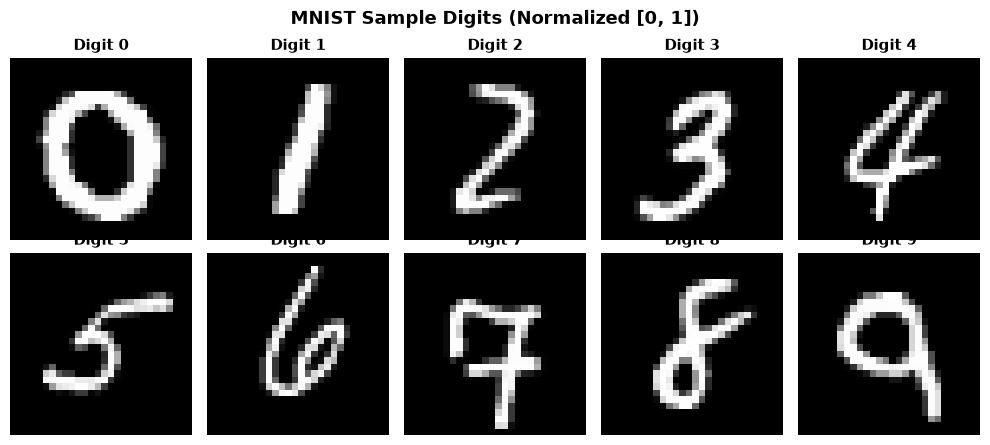

In [5]:
X_tr_mnist, y_tr_mnist, X_te_mnist, y_te_mnist, m_meta = U.load_mnist(n_train=5000, n_test=2000)
print(f"MNIST Subset:")
print(f" - X_train: {X_tr_mnist.shape}, min={X_tr_mnist.min():.2f}, max={X_tr_mnist.max():.2f}")
print(f" - X_test : {X_te_mnist.shape}")

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_tr_mnist == i)[0][0]
    ax.imshow(X_tr_mnist[idx, 0], cmap="gray")
    ax.set_title(f"Digit {i}", fontsize=11, fontweight="bold")
    ax.axis("off")
plt.suptitle("MNIST Sample Digits (Normalized [0, 1])", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Kiểm kê Bộ Dữ liệu Ảnh: CIFAR-10

Bộ ảnh màu tự nhiên $3 \times 32 \times 32$, gồm 10 lớp vật thể. Độ phức tạp thị giác cao hơn nhiều so với MNIST.

CIFAR-10: train (5000, 3, 32, 32) / test (2000, 3, 32, 32), 10 classes
CIFAR-10 Subset:
 - X_train: (5000, 3, 32, 32), min=-2.00, max=2.11
 - X_test : (2000, 3, 32, 32)


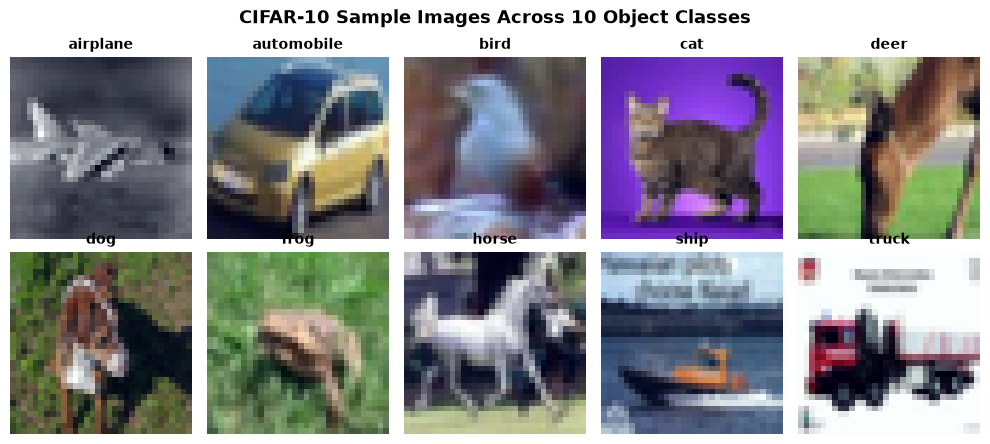

In [6]:
X_tr_cifar, y_tr_cifar, X_te_cifar, y_te_cifar, c_meta = U.load_cifar10(n_train=5000, n_test=2000)
cifar_names = c_meta.get('classes', ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])
print(f"CIFAR-10 Subset:")
print(f" - X_train: {X_tr_cifar.shape}, min={X_tr_cifar.min():.2f}, max={X_tr_cifar.max():.2f}")
print(f" - X_test : {X_te_cifar.shape}")

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_tr_cifar == i)[0][0]
    img = X_tr_cifar[idx].transpose(1, 2, 0)
    # un-normalize for visualization
    img_disp = (img - img.min()) / (img.max() - img.min() + 1e-7)
    ax.imshow(np.clip(img_disp, 0, 1))
    ax.set_title(cifar_names[i], fontsize=10, fontweight="bold")
    ax.axis("off")
plt.suptitle("CIFAR-10 Sample Images Across 10 Object Classes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Bảng Tổng Hợp Kiểm Kê Tính Toàn Vẹn Thực Nghiệm

In [7]:
inventory_data = [
    {"Tên bộ dữ liệu": "Diabetes 130-US", "Kiểu dữ liệu": "Dữ liệu bảng (Tabular)", "Kích thước gốc": "101,766 dòng x 50 cột", "Đầu vào mạng": "179 features (One-Hot)", "Số lớp": 3, "Tập Train / Test": "55,979 / 13,994", "Notebook thực nghiệm": "01_diabetes130.ipynb"},
    {"Tên bộ dữ liệu": "MNIST Subset", "Kiểu dữ liệu": "Ảnh grayscale (1 channel)", "Kích thước gốc": "70,000 ảnh 28x28", "Đầu vào mạng": "(1, 28, 28) hoặc (1, 32, 32)", "Số lớp": 10, "Tập Train / Test": "5,000 / 2,000", "Notebook thực nghiệm": "02_mnist.ipynb / 06_lenet"},
    {"Tên bộ dữ liệu": "MNIST Full", "Kiểu dữ liệu": "Ảnh grayscale (1 channel)", "Kích thước gốc": "70,000 ảnh 28x28", "Đầu vào mạng": "(1, 28, 28) hoặc (1, 32, 32)", "Số lớp": 10, "Tập Train / Test": "60,000 / 10,000", "Notebook thực nghiệm": "02_mnist.ipynb / 06_lenet"},
    {"Tên bộ dữ liệu": "CIFAR-10 Subset", "Kiểu dữ liệu": "Ảnh màu RGB (3 channels)", "Kích thước gốc": "60,000 ảnh 32x32", "Đầu vào mạng": "(3, 32, 32)", "Số lớp": 10, "Tập Train / Test": "5,000 / 2,000", "Notebook thực nghiệm": "03_cifar10.ipynb / 07_lenet"},
    {"Tên bộ dữ liệu": "CIFAR-10 Full", "Kiểu dữ liệu": "Ảnh màu RGB (3 channels)", "Kích thước gốc": "60,000 ảnh 32x32", "Đầu vào mạng": "(3, 32, 32)", "Số lớp": 10, "Tập Train / Test": "50,000 / 10,000", "Notebook thực nghiệm": "03_cifar10.ipynb / 04_compare"},
]
df_inv = pd.DataFrame(inventory_data)
display(df_inv)
print("\n[OK] Toàn bộ dữ liệu kiểm kê thành công, sẵn sàng thực nghiệm.")

,Tên bộ dữ liệu,Kiểu dữ liệu,Kích thước gốc,Đầu vào mạng,Số lớp,Tập Train / Test,Notebook thực nghiệm
0,Diabetes 130-US,Dữ liệu bảng (Tabular),"101,766 dòng x 50 cột",179 features (One-Hot),3,"55,979 / 13,994",01_diabetes130.ipynb
1,MNIST Subset,Ảnh grayscale (1 channel),"70,000 ảnh 28x28","(1, 28, 28) hoặc (1, 32, 32)",10,"5,000 / 2,000",02_mnist.ipynb / 06_lenet
2,MNIST Full,Ảnh grayscale (1 channel),"70,000 ảnh 28x28","(1, 28, 28) hoặc (1, 32, 32)",10,"60,000 / 10,000",02_mnist.ipynb / 06_lenet
3,CIFAR-10 Subset,Ảnh màu RGB (3 channels),"60,000 ảnh 32x32","(3, 32, 32)",10,"5,000 / 2,000",03_cifar10.ipynb / 07_lenet
4,CIFAR-10 Full,Ảnh màu RGB (3 channels),"60,000 ảnh 32x32","(3, 32, 32)",10,"50,000 / 10,000",03_cifar10.ipynb / 04_compare



[OK] Toàn bộ dữ liệu kiểm kê thành công, sẵn sàng thực nghiệm.
